# Sentiment Analysis using NLP Pipeline & Machine Learning Models

## Objective
To build an end-to-end sentiment analysis system using NLP preprocessing, feature engineering, and multiple machine learning models. The goal is to compare model performance using evaluation metrics such as Accuracy, Precision, Recall, and F1-score.

In [1]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')

In [2]:
df = pd.read_csv("IMDB_dataset.csv") 
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [5]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## 2. NLP Preprocessing

The following preprocessing steps are applied:
- Lowercasing
- Removing punctuation
- Removing stopwords
- Tokenization
- Lemmatization
- Removing special characters and URLs

In [6]:
# Lowercase
df['review'] = df['review'].str.lower()

# Remove URLs and special characters
df['review'] = df['review'].apply(lambda x: re.sub(r"http\S+|www\S+|[^a-zA-Z ]", "", x))

# Remove punctuation
df['review'] = df['review'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

# Tokenization (CREATE tokens column here ✅)
df['tokens'] = df['review'].apply(word_tokenize)

# Stopwords removal
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Lemmatization
lemmatizer = WordNetLemmatizer()
df['cleaned_review'] = df['tokens'].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x]))

# Final output
df.head()

,review,sentiment,tokens,cleaned_review
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, oz, epis...",one reviewer mentioned watching oz episode you...
1,a wonderful little production br br the filmin...,positive,"[wonderful, little, production, br, br, filmin...",wonderful little production br br filming tech...
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,negative,"[basically, theres, family, little, boy, jake,...",basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


## 3. Feature Engineering

Text data is converted into numerical features using:
- Bag of Words (BoW)
- TF-IDF (Term Frequency - Inverse Document Frequency)

In [7]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_review']).toarray()

In [8]:
# Encode labels
df['sentiment'] = df['sentiment'].map({'negative':0, 'positive':1})
y = df['sentiment']

## 4. Train-Test Split

The dataset is split into training and testing sets to evaluate model performance.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Model Building

The following machine learning models are trained:
- Logistic Regression
- Naive Bayes
- Decision Tree

In [10]:
lr = LogisticRegression()
nb = MultinomialNB()
dt = DecisionTreeClassifier()

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 6. Model Evaluation

Models are evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score

In [11]:
def evaluate(model):
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

In [12]:
print("Logistic Regression")
evaluate(lr)

print("\nNaive Bayes")
evaluate(nb)

print("\nDecision Tree")
evaluate(dt)

Logistic Regression
Accuracy: 0.8845
Precision: 0.8847329583606708
Recall: 0.8845
F1 Score: 0.8844691448138612

Naive Bayes
Accuracy: 0.8517
Precision: 0.8517051230435582
Recall: 0.8517
F1 Score: 0.8516953977240853

Decision Tree
Accuracy: 0.7136
Precision: 0.7136731432916281
Recall: 0.7136
F1 Score: 0.7136016038410264


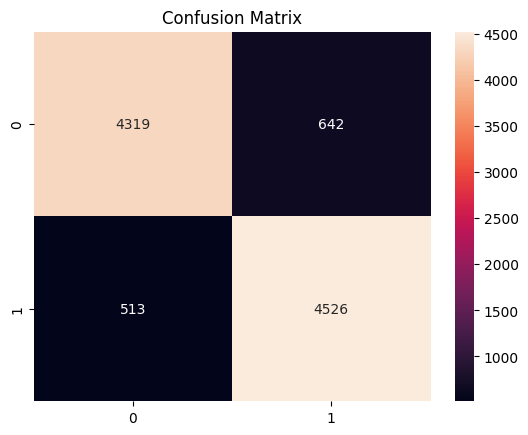

In [13]:
cm = confusion_matrix(y_test, lr.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 7. Comparison & Insights

• TF-IDF performed better than Bag of Words in capturing important textual patterns.
• Logistic Regression achieved the highest accuracy among all models.
• Naive Bayes performed well and is computationally efficient but slightly less accurate.
• Decision Tree showed lower performance and signs of overfitting on training data.
• Binary classification (positive vs negative) made the problem simpler and improved model performance.

## Conclusion

This project demonstrated how NLP preprocessing and feature engineering significantly impact model performance. Among the models, Logistic Regression combined with TF-IDF achieved the best results. Proper text cleaning, tokenization, and lemmatization helped improve accuracy. Overall, the project highlights the importance of choosing the right preprocessing techniques and models for sentiment analysis tasks.